In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import itertools
import plotly.graph_objects as go
from datetime import datetime,date
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor



In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/BIA Internship/Warehouse_and_Retail_Sales.2.csv")
df.head(5)

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [ ]:
print("SHAPE")
print(df.shape)

SHAPE
(307645, 9)


In [ ]:
print("INFO")
print(df.info())

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307645 entries, 0 to 307644
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   YEAR              307645 non-null  int64  
 1   MONTH             307645 non-null  int64  
 2   SUPPLIER          307645 non-null  object 
 3   ITEM CODE         307645 non-null  object 
 4   ITEM DESCRIPTION  307645 non-null  object 
 5   ITEM TYPE         307645 non-null  object 
 6   RETAIL SALES      307645 non-null  float64
 7   RETAIL TRANSFERS  307645 non-null  float64
 8   WAREHOUSE SALES   307645 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.1+ MB
None


In [ ]:
print("Types")
print(df.dtypes)

Types
YEAR                  int64
MONTH                 int64
SUPPLIER             object
ITEM CODE            object
ITEM DESCRIPTION     object
ITEM TYPE            object
RETAIL SALES        float64
RETAIL TRANSFERS    float64
WAREHOUSE SALES     float64
dtype: object


In [ ]:
print("MISSING VALUES")
mv = df.isnull().sum()
print(mv)

MISSING VALUES
YEAR                0
MONTH               0
SUPPLIER            0
ITEM CODE           0
ITEM DESCRIPTION    0
ITEM TYPE           0
RETAIL SALES        0
RETAIL TRANSFERS    0
WAREHOUSE SALES     0
dtype: int64


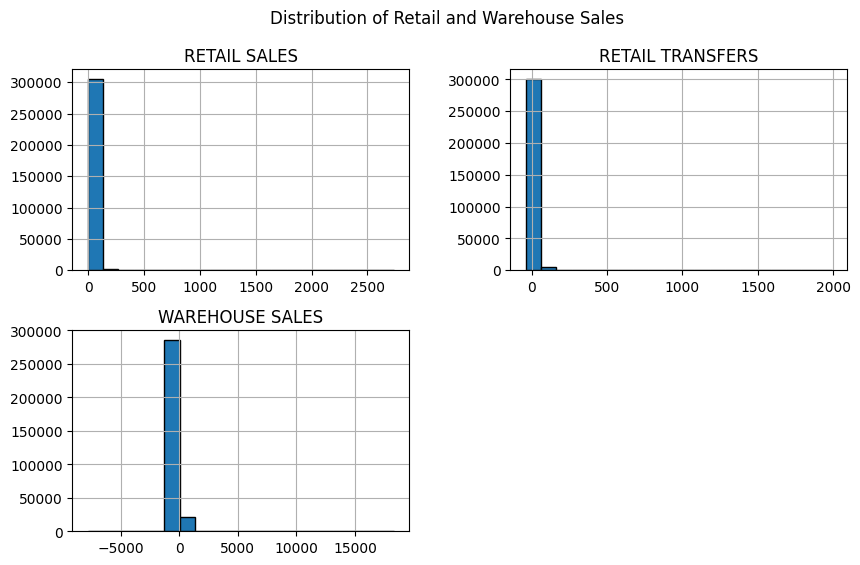

In [ ]:
# Plot histograms of the numerical columns
df[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']].hist(figsize=(10, 6), bins=20, edgecolor='black')
plt.suptitle('Distribution of Retail and Warehouse Sales')
plt.show()


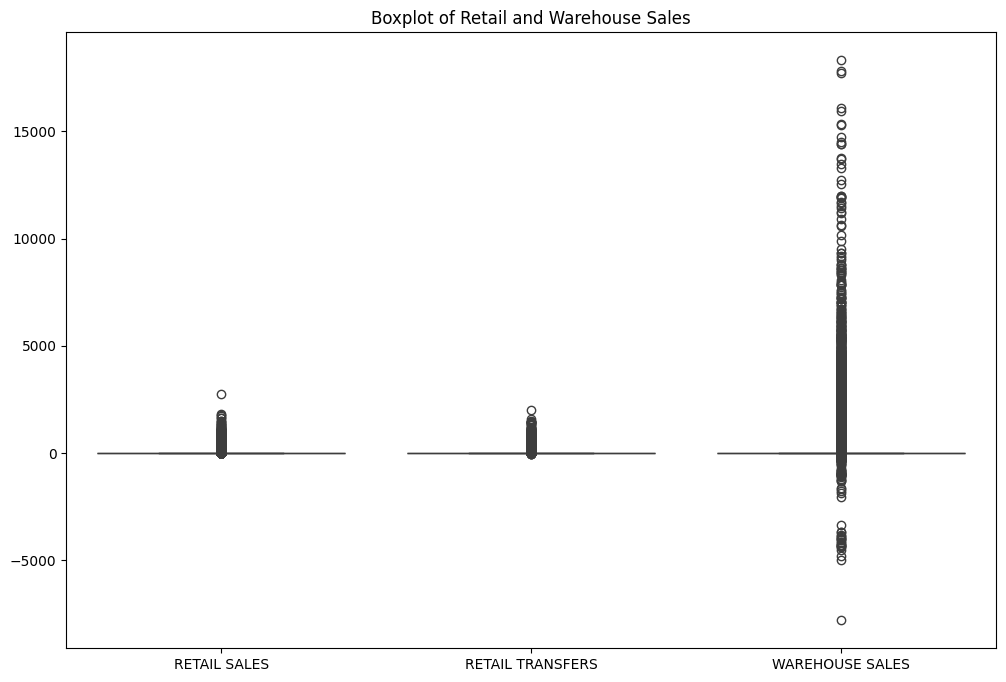

In [ ]:
# Boxplot to check for outliers in numerical columns
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']])
plt.title('Boxplot of Retail and Warehouse Sales')
plt.show()


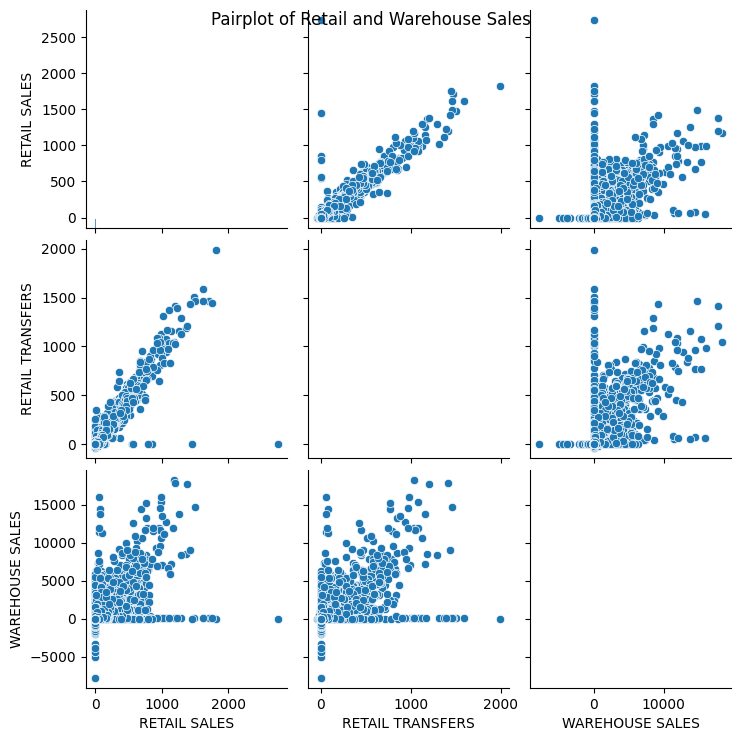

In [ ]:
# Pairplot to visualize relationships between features
sns.pairplot(df[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']])
plt.suptitle('Pairplot of Retail and Warehouse Sales')
plt.show()


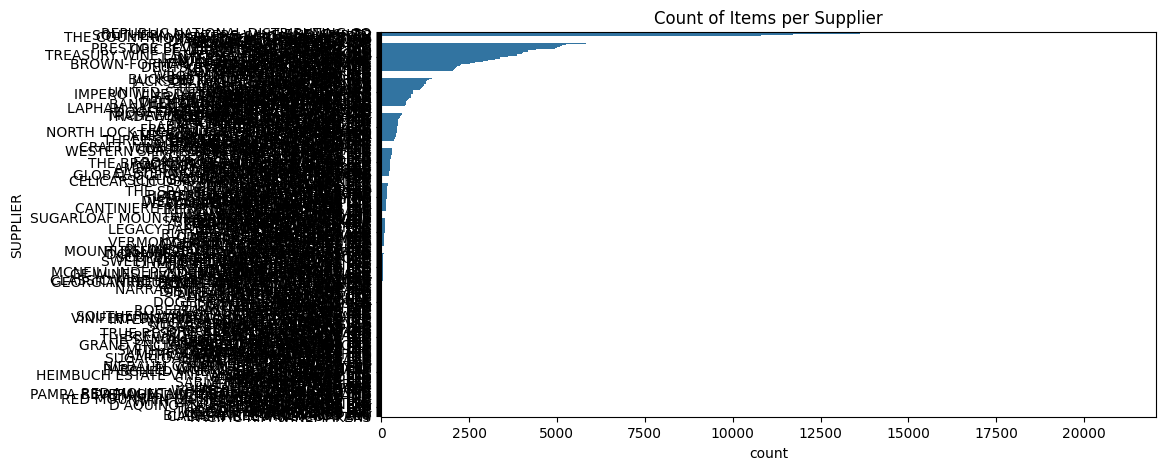

In [ ]:
# Bar plot for categorical column SUPPLIER
plt.figure(figsize=(10, 5))
sns.countplot(y='SUPPLIER', data=df, order=df['SUPPLIER'].value_counts().index)
plt.title('Count of Items per Supplier')
plt.show()


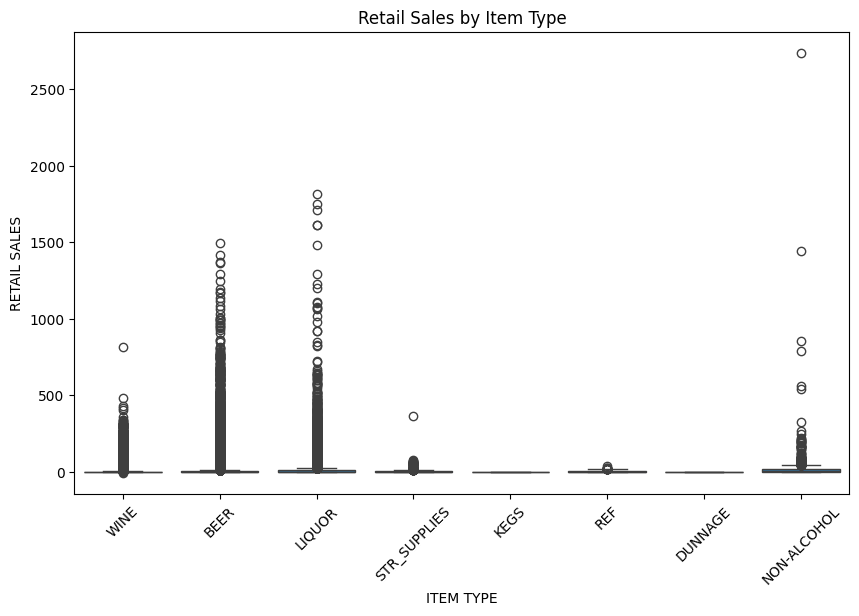

In [ ]:
# Boxplot to visualize the relationship between ITEM TYPE and RETAIL SALES
plt.figure(figsize=(10, 6))
sns.boxplot(x='ITEM TYPE', y='RETAIL SALES', data=df)
plt.title('Retail Sales by Item Type')
plt.xticks(rotation=45)
plt.show()


In [ ]:
from scipy import stats

# Calculate z-scores for RETAIL SALES
z_scores = stats.zscore(df[['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']])

# Identify outliers (z-score > 3 or < -3)
outliers = (z_scores > 3) | (z_scores < -3)
print(df[outliers.any(axis=1)])


        YEAR  MONTH                      SUPPLIER ITEM CODE  \
170     2020      1  HEAVEN HILL DISTILLERIES INC     11088   
253     2020      1                    SAZERAC CO     11703   
257     2020      1            JIM BEAM BRANDS CO     11746   
258     2020      1            JIM BEAM BRANDS CO     11762   
259     2020      1            JIM BEAM BRANDS CO     11770   
...      ...    ...                           ...       ...   
307534  2020      9            E & J GALLO WINERY     71764   
307558  2020      9            ANHEUSER BUSCH INC     91030   
307588  2020      9            ANHEUSER BUSCH INC      8788   
307600  2020      9            ANHEUSER BUSCH INC     97578   
307641  2020      9            ANHEUSER BUSCH INC     97918   

                                   ITEM DESCRIPTION ITEM TYPE  RETAIL SALES  \
170       EVAN WILLIAMS BLACK SOUR MASH 7YR - 750ML    LIQUOR        109.97   
253                      KENTUCKY GENTLEMAN - 1.75L    LIQUOR        134.61   
257   

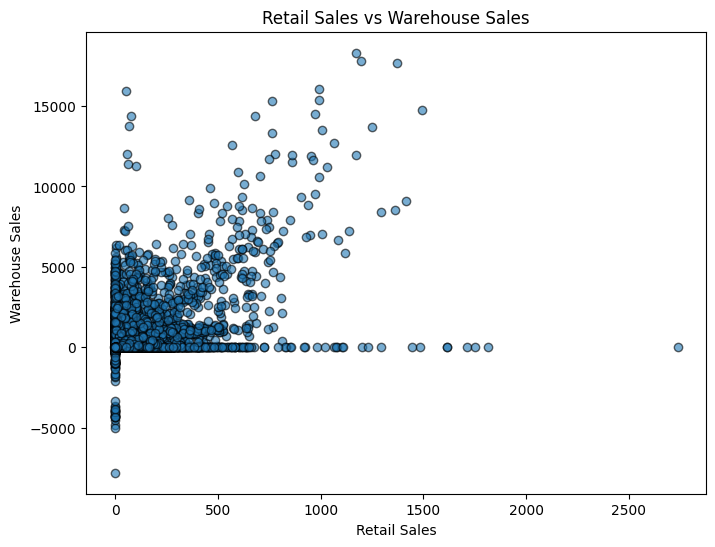

In [ ]:
# Scatter plot between Retail Sales and Warehouse Sales
plt.figure(figsize=(8, 6))
plt.scatter(df['RETAIL SALES'], df['WAREHOUSE SALES'], alpha=0.6, edgecolor='k')
plt.xlabel('Retail Sales')
plt.ylabel('Warehouse Sales')
plt.title('Retail Sales vs Warehouse Sales')
plt.show()


In [ ]:
features = ['RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES']


In [ ]:
# Standardize the numerical features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

In [ ]:
# Summary statistics for numerical columns
print(df.describe())

# Summary statistics for categorical columns
print(df.describe(include=['object']))


                YEAR          MONTH   RETAIL SALES  RETAIL TRANSFERS  \
count  307645.000000  307645.000000  307645.000000     307645.000000   
mean     2018.438525       6.423862       7.024003          6.936465   
std         1.083061       3.461812      30.986095         30.237195   
min      2017.000000       1.000000      -6.490000        -38.490000   
25%      2017.000000       3.000000       0.000000          0.000000   
50%      2019.000000       7.000000       0.320000          0.000000   
75%      2019.000000       9.000000       3.260000          3.000000   
max      2020.000000      12.000000    2739.000000       1990.830000   

       WAREHOUSE SALES  
count    307645.000000  
mean         25.294597  
std         249.916798  
min       -7800.000000  
25%           0.000000  
50%           1.000000  
75%           5.000000  
max       18317.000000  
                                 SUPPLIER ITEM CODE          ITEM DESCRIPTION  \
count                              307645    

In [ ]:
inertia = []
K = range(1,10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

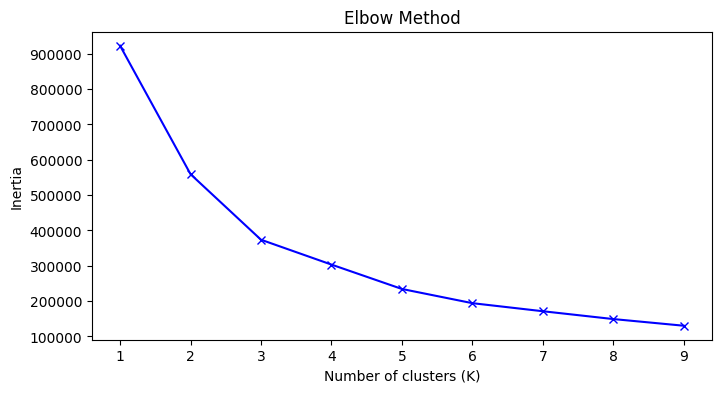

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)


In [ ]:
print(df[['YEAR', 'MONTH', 'ITEM DESCRIPTION', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES', 'Cluster']].head(100))

    YEAR  MONTH                              ITEM DESCRIPTION  RETAIL SALES  \
0   2020      1                           BOOTLEG RED - 750ML          0.00   
1   2020      1                     MOMENT DE PLAISIR - 750ML          0.00   
2   2020      1           S SMITH ORGANIC PEAR CIDER - 18.7OZ          0.00   
3   2020      1                 SCHLINK HAUS KABINETT - 750ML          0.00   
4   2020      1                SANTORINI GAVALA WHITE - 750ML          0.82   
..   ...    ...                                           ...           ...   
95  2020      1               SAUZA HORNITOS REPOSATO - 375ML          0.16   
96  2020      1            EFFEN VODKA - BLACK CHERRY - 375ML          0.08   
97  2020      1                   MAKERS MARK BOURBON - 375ML         26.25   
98  2020      1  TWO JAMES JOHNNY SMOKING GUN WHISKEY - 750ML          0.17   
99  2020      1     BRINLEY GOLD SHIPWRECK SPICED RUM - 750ML          0.17   

    RETAIL TRANSFERS  WAREHOUSE SALES  Cluster  
0 

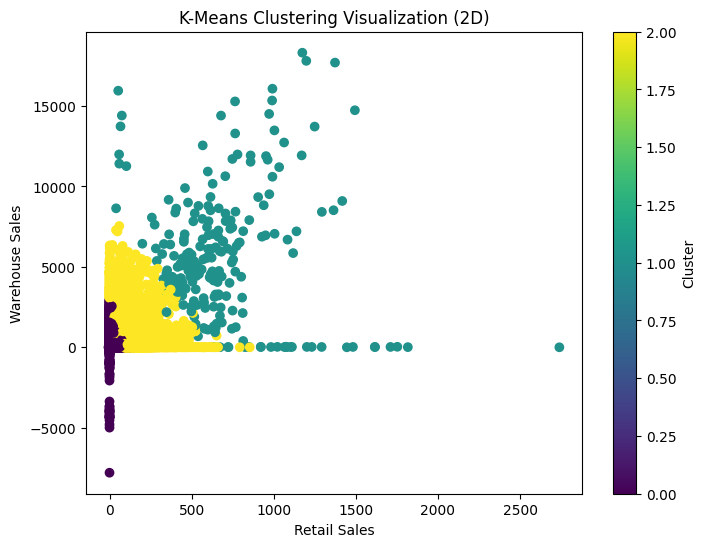

In [ ]:
import matplotlib.pyplot as plt

# Scatter plot using two features for visualization
plt.figure(figsize=(8, 6))

# Plot the points, using different colors for each cluster
plt.scatter(df['RETAIL SALES'], df['WAREHOUSE SALES'], c=df['Cluster'], cmap='viridis', marker='o')

# Add labels and title
plt.xlabel('Retail Sales')
plt.ylabel('Warehouse Sales')
plt.title('K-Means Clustering Visualization (2D)')
plt.colorbar(label='Cluster')
plt.show()


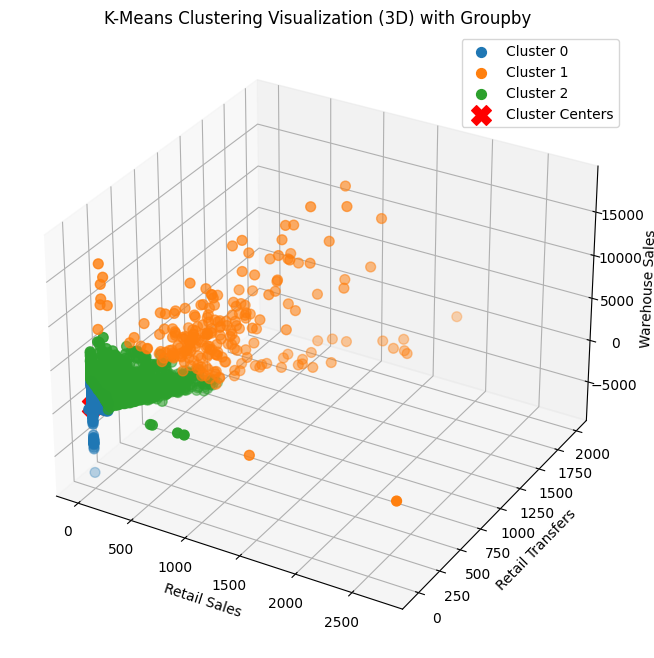

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Group the data by clusters
grouped = df.groupby('Cluster')

# Iterate through each group (cluster) and plot separately
for name, group in grouped:
    ax.scatter(group['RETAIL SALES'], group['RETAIL TRANSFERS'], group['WAREHOUSE SALES'],
               label=f'Cluster {name}', s=50)  # 's=50' sets the size of the markers


centers = kmeans.cluster_centers_  # Get the cluster centers from the KMeans algorithm
ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2],
           c='red', s=200, marker='X', label='Cluster Centers')  # Plot centers with red 'X'


# Set axis labels
ax.set_xlabel('Retail Sales')
ax.set_ylabel('Retail Transfers')
ax.set_zlabel('Warehouse Sales')

# Add a legend to indicate different clusters
plt.legend()

# Add a title and show the plot
plt.title('K-Means Clustering Visualization (3D) with Groupby')
plt.show()
